In [1]:
import torch
import clip
import os
from torchvision import transforms, datasets
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

from utils import clip_analysis_utils
from utils import similarity

In [2]:
clip_name = "ViT-B/16"     #"ViT-B/16" or "ALIGN"
# concept_set = "data/concept_sets/cub_filtered.txt"
dataset = "cub"
d_train = dataset + "_train"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

dataset_path = os.path.join(os.getcwd(), "Data\CUB_200_2011")
used_ground_truth_concepts = False  #wether we compare it to the original CUB attributes or not
concept_file = "run_final_concepts.txt"
comparison_to_ground_truth = 'class_ground_truth' #which field to use for comparison if using ground truth concepts. class_ground_truth -> probability per class straight from file. ground_truth_mean -> mean over images in class from is_present attribute.
use_certainty = True  #whether to use certainty information from attributes file or just standard is_present

In [3]:
#definitions:
def my_similarity(a, b):
    return a @ b.T  #dot product

In [4]:
#get true concepts for all image
attributes_cub = clip_analysis_utils.parse_attributes_file(dataset_path, "attributes\\image_attribute_labels.txt", use_certainty)

In [5]:
#gets the per class predicted probabilities for each concept to be present
attributes_cub_class = clip_analysis_utils.parse_attributes_continuous_file(dataset_path, "attributes\\class_attribute_labels_continuous.txt")

In [6]:
#create list of concepts, based on attributes file
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = get_cleaned_concepts(dataset_path, "attributes.txt") #original CUB attributes
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = get_cleaned_concepts(os.path.join(os.getcwd(), "Data\Concept_sets"), "cub_filtered.txt", used_ground_truth_concepts)  #filtered concepts
#cleaned_concepts, cleaned_not_concepts, grouped_concepts = get_cleaned_concepts(os.path.join(os.getcwd(), ""), "run_final_concepts.txt", used_ground_truth_concepts)  #filtered concepts
cleaned_concepts, cleaned_not_concepts, grouped_concepts = clip_analysis_utils.get_cleaned_concepts(os.path.join(os.getcwd(), "test"), concept_file, used_ground_truth_concepts)  #filtered concepts

In [7]:
target_mean = [0.485, 0.456, 0.406]
target_std = [0.229, 0.224, 0.225]
preprocess = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                   transforms.ToTensor(), transforms.Normalize(mean=target_mean, std=target_std)])
data = datasets.ImageFolder("data\CUB_200_2011\images", preprocess)

mult_scores, not_mult_scores = clip_analysis_utils.get_clip_similarity_all(clip_name, cleaned_concepts, my_similarity, cleaned_not_concepts, device)

100%|██████████| 1/1 [00:00<00:00, 53.84it/s]


In [8]:
# If only one concept is used, get its index in the original CUB attributes and compare to that
ground_truth_concept_idx = -1
if len(cleaned_concepts) == 1:
    original_concepts = clip_analysis_utils.get_cleaned_concepts(dataset_path, "attributes.txt")[0]  #original CUB attributes
    #get concept index for true concept
    for i, concept in enumerate(original_concepts):
        if concept == cleaned_concepts[0]:
            ground_truth_concept_idx = i + 1  #attribute ids start from 1
            print("Found ground truth concept'", cleaned_concepts[0],"' at idx: ", ground_truth_concept_idx)
            break

#calcuate per-class statistics
classes_dict = data.class_to_idx.copy()
last_idx = -1
for key, value in tqdm(classes_dict.items()):
    #idx = [j for j in range(len(data)) if data[j][1] == value] too slow!
    idx = []
    ground_truth = []
    for j in range(last_idx+1,len(data)):
        if data[j][1] == value:
            idx.append(j)
            if ground_truth_concept_idx >= 0: ground_truth.append(attributes_cub[j+1][ground_truth_concept_idx][0])  #image ids in attributes file start from 1
        else:
            last_idx = j
            break
    mean_pos = mult_scores[idx].mean()
    not_mean_pos = not_mult_scores[idx].mean()
    if ground_truth_concept_idx >= 0:
        classes_dict[key] = {"idx": value, "mean": mean_pos.item(), "not_mean": not_mean_pos.item(), "mean_delta": (mean_pos - not_mean_pos).item(), "std": mult_scores[idx].std().item(), "not_std": not_mult_scores[idx].std().item(), "ground_truth_mean": np.mean(ground_truth), "class_ground_truth": attributes_cub_class[value][ground_truth_concept_idx - 1]/100}
    else:
        classes_dict[key] = {"idx": value, "mean": mean_pos.item(), "not_mean": not_mean_pos.item(), "mean_delta": (mean_pos - not_mean_pos).item(), "std": mult_scores[idx].std().item(), "not_std": not_mult_scores[idx].std().item()}


Found ground truth concept' has wing color yellow ' at idx:  16


100%|██████████| 200/200 [00:55<00:00,  3.61it/s]


In [9]:
if ground_truth_concept_idx >= 0:
    print(f"{'id':<3} {'Bird Name':<35} {'Mean':>5}  {'Mean Δ':>7} | {'Std':>5} | {'Ground Truth':>7}")
    print("-" * 75)
    ground_truth_mean = []
    for bird, stats in classes_dict.items():
        idx, name = bird.split('.')  # remove the numeric prefix
        print(f"{idx:<3} {name:<35} {stats['mean']:.3f}  {stats['mean_delta']:6.3f} | {stats['std']:.3f} | {stats[comparison_to_ground_truth]:.3f}")
        ground_truth_mean.append(stats['ground_truth_mean'])
    print("overall mean:", mult_scores.mean().item(), " -- overall delta:", mult_scores.mean().item() - not_mult_scores.mean().item(), " | std:", mult_scores.std().item(), " | overall GT mean:", np.mean(ground_truth_mean))
else:
    print(f"{'id':<3} {'Bird Name':<35} {'Mean':>5}  {'Mean Δ':>7} | {'Std':>4}")
    print("-" * 65)
    for bird, stats in classes_dict.items():
        idx, name = bird.split('.')  # remove the numeric prefix
        print(f"{idx:<3} {name:<35} {stats['mean']:.3f}  {stats['mean_delta']:6.3f} | {stats['std']:.3f}")
    print("overall mean:", mult_scores.mean().item(), " -- overall delta:", mult_scores.mean().item() - not_mult_scores.mean().item(), " | std:", mult_scores.std().item())

id  Bird Name                            Mean   Mean Δ |   Std | Ground Truth
---------------------------------------------------------------------------
001 Black_footed_Albatross              0.237  -0.005 | 0.009 | 0.000
002 Laysan_Albatross                    0.240  -0.006 | 0.011 | 0.000
003 Sooty_Albatross                     0.238  -0.007 | 0.013 | 0.000
004 Groove_billed_Ani                   0.238   0.006 | 0.011 | 0.000
005 Crested_Auklet                      0.233  -0.002 | 0.011 | 0.000
006 Least_Auklet                        0.237   0.001 | 0.009 | 0.000
007 Parakeet_Auklet                     0.234  -0.002 | 0.012 | 0.000
008 Rhinoceros_Auklet                   0.235  -0.000 | 0.010 | 0.022
009 Brewer_Blackbird                    0.242   0.005 | 0.011 | 0.021
010 Red_winged_Blackbird                0.242   0.009 | 0.010 | 0.274
011 Rusty_Blackbird                     0.238   0.012 | 0.011 | 0.019
012 Yellow_headed_Blackbird             0.279   0.009 | 0.009 | 0.016
013 Bo

001 Black_footed_Albatross              0.237  -0.005 | 0.009 | 0.000
002 Laysan_Albatross                    0.240  -0.006 | 0.011 | 0.000
003 Sooty_Albatross                     0.238  -0.007 | 0.013 | 0.000
004 Groove_billed_Ani                   0.238   0.006 | 0.011 | 0.000
005 Crested_Auklet                      0.233  -0.002 | 0.011 | 0.000
006 Least_Auklet                        0.237   0.001 | 0.009 | 0.000
007 Parakeet_Auklet                     0.234  -0.002 | 0.012 | 0.000
015 Lazuli_Bunting                      0.249   0.016 | 0.010 | 0.000
018 Spotted_Catbird                     0.243   0.006 | 0.013 | 0.000
019 Gray_Catbird                        0.245   0.009 | 0.009 | 0.000
021 Eastern_Towhee                      0.241   0.013 | 0.011 | 0.000
022 Chuck_will_Widow                    0.233   0.007 | 0.013 | 0.000
023 Brandt_Cormorant                    0.235   0.002 | 0.010 | 0.000
024 Red_faced_Cormorant                 0.231   0.004 | 0.012 | 0.000
025 Pelagic_Cormoran

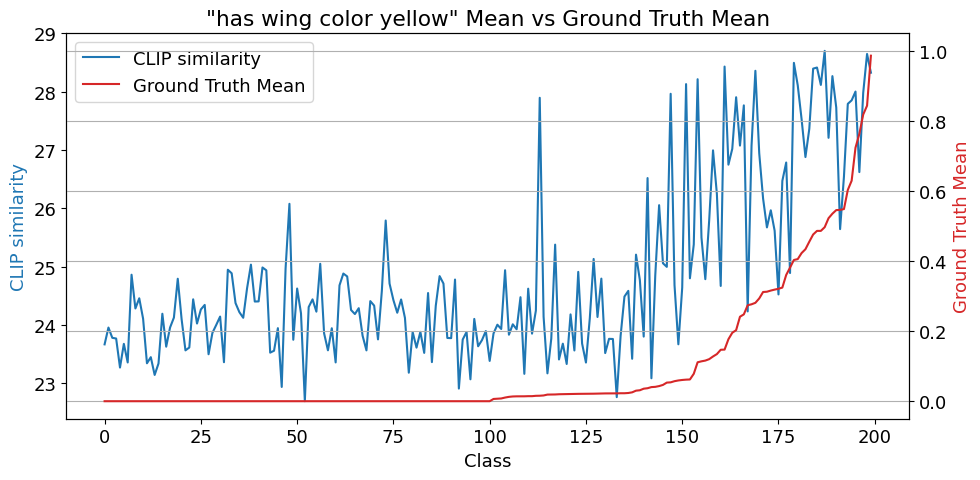

In [10]:
#sorted_items = sorted(classes_dict.items(), key=lambda x: x[1]['mean'])         #sorted by clip similarity
sorted_items = sorted(classes_dict.items(), key=lambda x: x[1][comparison_to_ground_truth])     #sorted by ground truth
plt.style.use("default")
plt.rcParams.update({'font.size': 13})

# Print sorted stats
for bird, stats in sorted_items:
    idx, name = bird.split('.')
    print(f"{idx:<3} {name:<35} {stats['mean']:.3f}  {stats['mean_delta']:6.3f} | {stats['std']:.3f} | {stats[comparison_to_ground_truth]:.3f}")


# --- Extract data for plotting ---
#idxs = [int(bird.split('.')[0]) for bird, _ in sorted_items]
means = [stats['mean']*100 for _, stats in sorted_items]
gt_means = [stats[comparison_to_ground_truth] for _, stats in sorted_items]
x_axis = np.arange(len(means))

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))
plt.plot(x_axis, means,  label='CLIP similarity', color='tab:blue')
ax1.set_ylabel("CLIP similarity", color='tab:blue')
ax1.set_xlabel("Class")
ax2 = ax1.twinx()
plt.plot(x_axis, gt_means, label='Ground Truth Mean', color='tab:red')
ax2.set_ylabel("Ground Truth Mean", color='tab:red')
ax2.set_ylim(-0.05, 1.05)
#ax1.set_ylim(17.4, 30.6)
plt.title(f'"{cleaned_concepts[0]}" Mean vs Ground Truth Mean')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.grid(True)
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.tight_layout()
plt.savefig(f'test\cutoff_problem\meanVSgroundtruth_{ground_truth_concept_idx}.png')
plt.show()

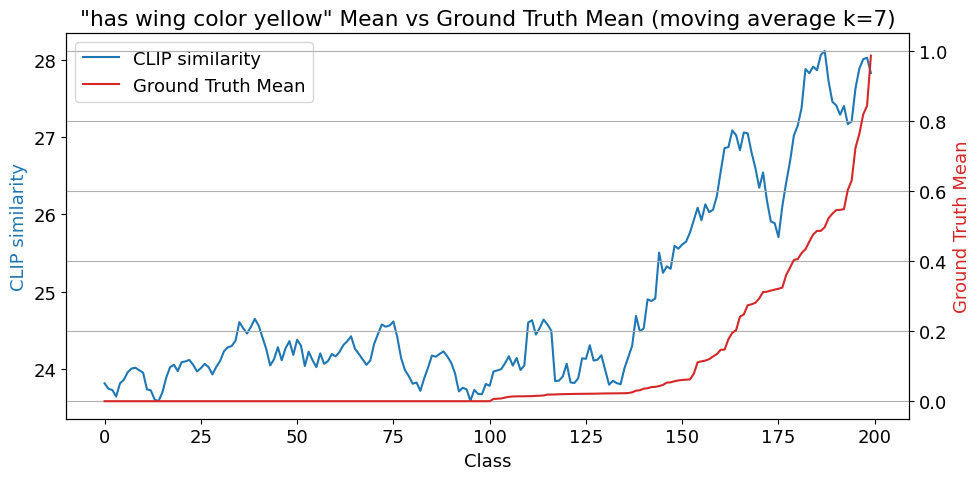

In [13]:
if "backup_means" not in locals():
    backup_means = means
    backup_gt_means = gt_means
    backup_concept = cleaned_concepts[0]

window_size = 7
weights = np.ones(window_size) / window_size
means_moving_average = means
means_moving_average = np.pad(means_moving_average, (int(window_size/2), int(window_size/2)), mode='reflect')
means_moving_average = np.convolve(means_moving_average, weights, mode='valid')

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))
plt.plot(x_axis, means_moving_average,  label='CLIP similarity', color='tab:blue')
ax1.set_ylabel("CLIP similarity", color='tab:blue')
ax1.set_xlabel("Class")
ax2 = ax1.twinx()
plt.plot(x_axis, gt_means, label='Ground Truth Mean', color='tab:red')
ax2.set_ylabel("Ground Truth Mean", color='tab:red')
ax2.set_ylim(-0.05, 1.05)
#ax1.set_ylim(17.4, 30.6)
plt.title(f'"{cleaned_concepts[0]}" Mean vs Ground Truth Mean (moving average k={window_size})')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.grid(True)
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
plt.tight_layout()
plt.savefig(f'test\cutoff_problem\meanVSgroundtruth_smoothed_{window_size}_{ground_truth_concept_idx}.png')
plt.show()


In [ ]:
#pearson correlation coefficient between ground truth and clip similarity
from scipy.stats import pearsonr
#print(means, gt_means)
correlation, p_value = pearsonr(means, gt_means)
print(f"Pearson correlation coefficient: {correlation:.4f}, p-value: {p_value:.4e}")

In [ ]:
# --- comparison to backup ---
from matplotlib.lines import Line2D
#has wing color yellow, has back color blue
backup_means_moving_average = backup_means
backup_means_moving_average = np.pad(
    backup_means_moving_average,
    (int(window_size/2), int(window_size/2)),
    mode='reflect'
)
backup_means_moving_average = np.convolve(
    backup_means_moving_average,
    weights,
    mode='valid'
)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Current run
ax1.plot(x_axis, means_moving_average, label=f'CLIP similarity "{cleaned_concepts[0]}"', color='tab:blue')
ax1.set_ylabel("CLIP similarity", color='tab:blue')
ax1.set_xlabel("Class")

# Backup run (dashed)
ax1.plot(
    x_axis,
    backup_means_moving_average,
    label=f'CLIP similarity "{backup_concept}"',
    color='tab:blue',
    linestyle='--'
)

ax2 = ax1.twinx()

# Current GT
ax2.plot(x_axis, gt_means, label=f'Ground Truth Mean "{cleaned_concepts[0]}"', color='tab:red')

# Backup GT
ax2.plot(
    x_axis,
    backup_gt_means,
    label=f'Ground Truth Mean "{backup_concept}"',
    color='tab:red',
    linestyle='--'
)

ax2.set_ylabel("Ground Truth Mean", color='tab:red')
ax2.set_ylim(-0.05, 1.05)
ax1.set_ylim(17, 29)

plt.title(f'"{cleaned_concepts[0]}" vs "{backup_concept}" comparison (moving average k={window_size})')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
#ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
lines = [Line2D([0], [0], color='tab:blue', label=cleaned_concepts[0]),
         Line2D([0], [0], color='tab:blue', linestyle='--', label=backup_concept),
        ]
labels = [cleaned_concepts[0], backup_concept]

ax1.legend(lines, labels,loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.savefig(f'test\\cutoff_problem\\doublecomparisonV3_smoothed_{window_size}_{ground_truth_concept_idx}.png')
plt.show()